# 02 | Training Efficiency Analysis, Error Diagnostics, and Deployment Prep

This notebook picks up from Notebook 01 after the training pipeline has stabilized. Instead of introducing a new training recipe, it answers three practical follow-up questions:

1. which data-loading settings make the pipeline fastest on the current machine
2. what kinds of test predictions the best Stage 2 model gets right or wrong
3. which deployment-oriented compression/export steps remain worthwhile after accuracy and latency are measured together

**Notebook outline**
- rebuild the same transforms used by the final training pipeline
- benchmark `DataLoader` settings such as `num_workers`, `batch_size`, `pin_memory`, and `prefetch_factor`
- reload the best exported Stage 2 `MobileNetV3-Large` weights from Notebook 01
- inspect correct and incorrect predictions with `Grad-CAM`
- test a representative structured pruning configuration and explain why pruning is not kept in the final path
- export the best Stage 2 model to ONNX and search for a viable static INT8 quantization candidate
- run a quick inference demo with the selected deployment artifact


In [ ]:
import gc
import os
import numpy as np
import pandas as pd
import random
from pathlib import Path
import copy

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision import models as tv_models
from torch.utils.data import DataLoader
from torch.nn.utils import prune

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import onnx
import onnxruntime as ort
from onnxruntime.quantization import (
    CalibrationDataReader,
    CalibrationMethod,
    QuantFormat,
    QuantType,
    quantize_static,
)

import importlib
import helper_utils
importlib.reload(helper_utils)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Profile Data-Loading Efficiency

Before touching model compression, it is worth checking whether the input pipeline itself is the bottleneck. This section measures how several `DataLoader` settings affect average epoch time on the current hardware.

The goal is pragmatic: choose settings that improve throughput without making the notebook unstable or needlessly memory-hungry.


In [3]:
# Training-time image transforms.
TRAIN_TRANSFORM = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # Match ImageNet normalization because the backbones start from ImageNet weights.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test transforms stay deterministic for fair evaluation.
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    # Use the same ImageNet normalization as the pretrained backbone so
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
# Create datasets
trainset = datasets.Food101(root="../data", split="train", transform=TRAIN_TRANSFORM, download=False)
testset = datasets.Food101(root="../data", split="test", transform=VAL_TRANSFORM, download=False) 

# Quick dataset-level check
print("Number of training samples:", len(trainset))
print("Number of test samples:", len(testset))

Number of training samples: 75750
Number of test samples: 25250


In [5]:
cpu_cores = os.cpu_count()
print(f"Number of available CPU cores: {cpu_cores}")

Number of available CPU cores: 14


All four sweeps below use the same basic protocol: isolate one `DataLoader` parameter, measure average epoch time, clean up memory, and then compare the resulting timings visually. That keeps the experiments simple enough to interpret while still being useful for configuration decisions.


### 1.1 Test `num_workers`

We start with `num_workers` because it often has the biggest effect on throughput. More workers can overlap preprocessing and batch preparation, but too many may create contention, shared-memory pressure, or platform-specific instability.


In [7]:
workers_to_test = [0, 2, 4, 8]

In [26]:
def experiment_workers(workers_to_test, trainset, device):
    # Initialize a dictionary to store the results
    worker_times = {}

    # Loop through each worker number you want to test
    for nw in workers_to_test:
        print(f"--- Testing Number of Workers = {nw} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            batch_size=64, 
                            shuffle=True,
                            # The 'num_workers' is set to the current value in the loop.
                            num_workers=nw
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            worker_times[nw] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of shared memory)
            print(f"\n❌ ERROR with {nw} workers. Likely a shared memory issue.")
            worker_times[nw] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return worker_times

In [ ]:
# Run the experiment to measure data-loading time for different numbers of workers.
worker_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name='worker_times', 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_workers, 
    # The worker counts to iterate over.
    cases=workers_to_test, 
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=True
)

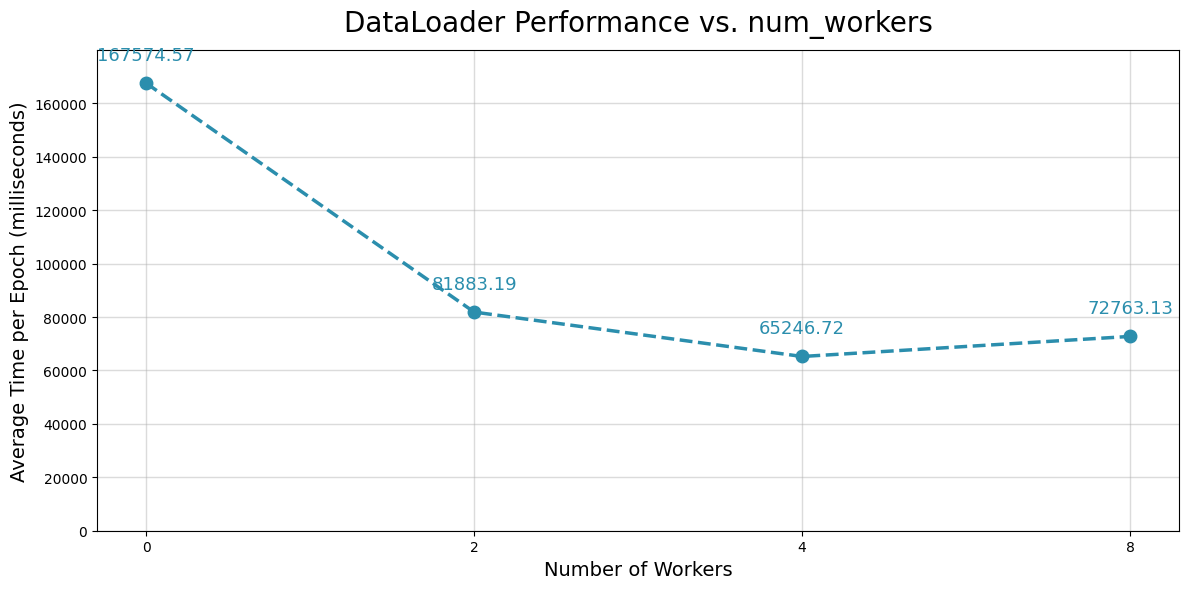

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. num_workers'}, xlabel='Number of Workers', ylabel='Average Time per Epoch (milliseconds)'>)

In [28]:
helper_utils.plot_performance_summary(
    worker_times, 
    title="DataLoader Performance vs. num_workers", 
    xlabel="Number of Workers", 
    ylabel="Average Time per Epoch (milliseconds)"
)

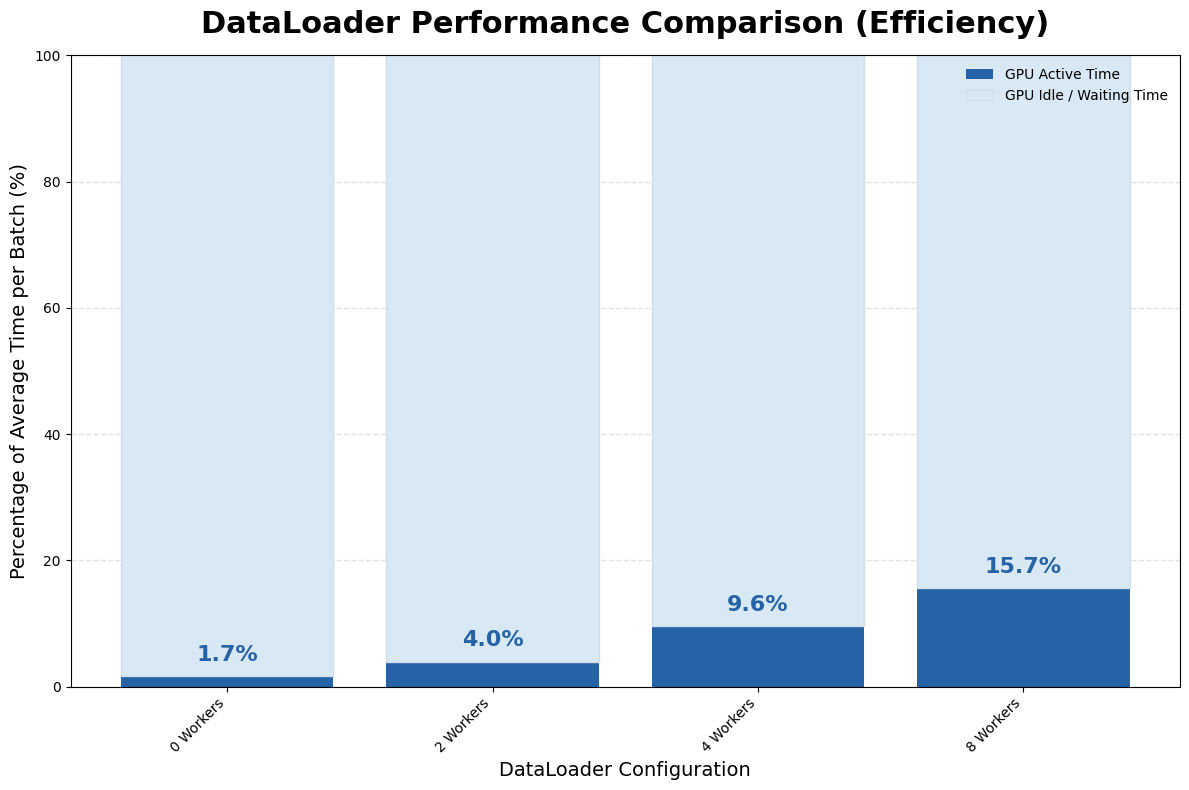

In [ ]:
# Build one DataLoader per worker setting so their throughput can be compared side by side.
loaders_to_compare = {
    f"{nw} Workers": DataLoader(trainset, batch_size=64, num_workers=nw) 
    for nw in workers_to_test
}

# Pass the generated loaders to the plotting helper.
helper_utils.visualize_dataloader_efficiency(loaders_to_compare, device)

# Clean up and release memory.
del loaders_to_compare
gc.collect()

# Clear the PyTorch MPS cache to free up GPU memory.
if torch.mps.is_available():
    torch.mps.empty_cache()

When reading the `num_workers` plots, the fastest setting is not automatically the best if it is unstable or fragile on reruns. The goal is to identify a practical operating point, not to chase a tiny timing gain at the cost of reliability.


### 1.2 Test `batch_size`

After choosing a reasonable worker count, we vary `batch_size` to measure the usual throughput-versus-memory trade-off. Larger batches reduce per-step overhead, but they can also saturate device memory or increase batch transfer cost.


In [30]:
batch_sizes_to_test = [ 32, 64, 128, 256]

In [31]:
def experiment_batch_sizes(batch_sizes_to_test, trainset, device):
    # Initialize a dictionary to store the results
    batch_size_times = {}

    # Loop through each batch size you want to test
    for bs in batch_sizes_to_test:
        print(f"--- Testing Batch Size = {bs} ---")
        
        # Create a new DataLoader instance for each specific test.
        loader = DataLoader(trainset, 
                            # The 'batch_size' is set to the current value in the loop.
                            batch_size=bs, 
                            shuffle=True,
                            num_workers=4 # Use the most efficient num_workers parameter
                        )
        
        # Handle potential runtime errors, especially out-of-memory
        try:
            # Time the data loading for one epoch and save it to the dictionary
            batch_size_times[bs] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs (often from running out of GPU memory),
            print(f"\n❌ ERROR with batch size {bs}. Likely a GPU memory issue.")
            batch_size_times[bs] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()
        
    return batch_size_times

In [ ]:
# Run the experiment to measure data-loading time for different batch sizes.
batch_size_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="batch_size_times", 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_batch_sizes,
    # The batch sizes to iterate over.
    cases=batch_sizes_to_test,
    # The dataset required by the experiment function.
    trainset=trainset,
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=True
)

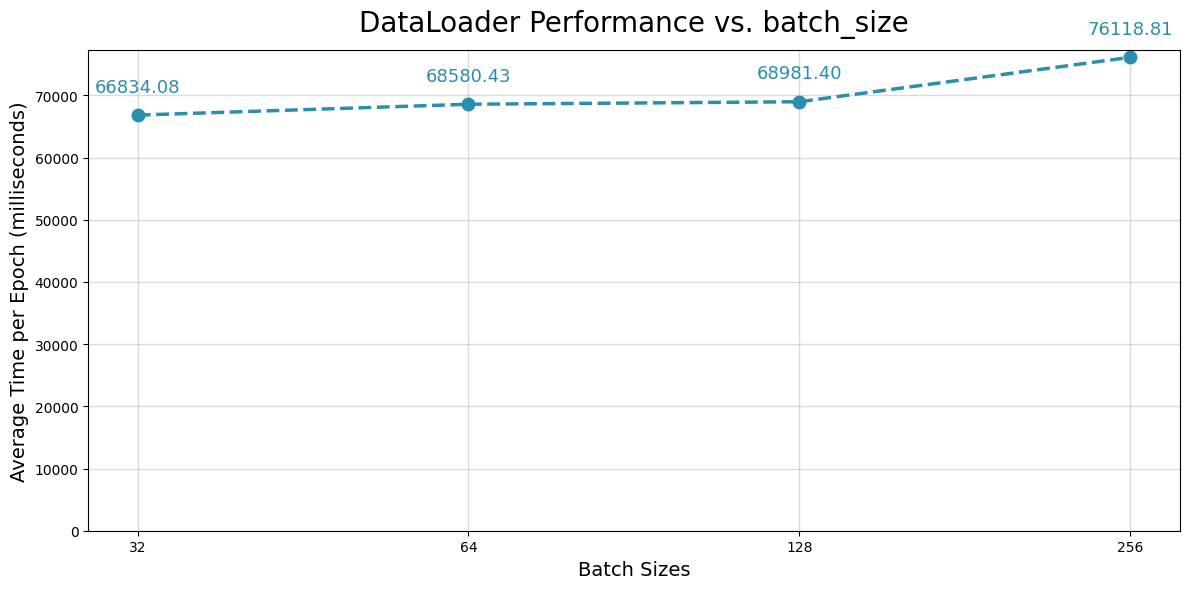

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. batch_size'}, xlabel='Batch Sizes', ylabel='Average Time per Epoch (milliseconds)'>)

In [33]:
helper_utils.plot_performance_summary(
    batch_size_times, 
    title="DataLoader Performance vs. batch_size", 
    xlabel="Batch Sizes", 
    ylabel="Average Time per Epoch (milliseconds)"
)

This batch-size sweep uses the previously chosen worker setting so the comparison isolates batching effects as much as possible. Any chosen value should still be cross-checked against real training memory usage later.


### 1.3 Test `pin_memory`

`pin_memory` is mainly helpful when host-to-device transfer is the limiting step, but its benefit depends heavily on the backend and platform. On a Mac workflow that primarily uses `MPS`, the gain is often limited, so the experiment below checks whether enabling it is actually worthwhile in this environment.


In [34]:
pin_memory_settings = [False, True]

In [35]:
def experiment_pin_memory(pin_memory_settings, trainset, device):
    # Initialize a dictionary to store the results
    pin_memory_times = {}

    # Loop through each pin_memory setting
    for setting in pin_memory_settings:
        print(f"--- Testing with pin_memory = {setting} ---")
        
        # Create a DataLoader with the current pin_memory setting
        loader = DataLoader(trainset,
                            batch_size=32, # Use the most efficient batch_size parameter
                            num_workers=4, # Use the most efficient num_workers parameter
                            shuffle=True,
                            # The 'pin_memory' is set to the current boolean value in the loop.
                            pin_memory=setting
                        )
        
        try:
            # Measure performance and store the result in the dictionary
            pin_memory_times[setting] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # Print an error message if an exception occurs
            print(f"\n❌ An error occurred with pin_memory = {setting}: {e}")
            pin_memory_times[setting] = float('inf')
            
        # --- Memory Cleanup for each iteration ---
        del loader
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return pin_memory_times

In [ ]:
# Run the experiment to measure data-loading time with pin_memory set to False or True.
pin_memory_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="pin_memory_times",
    # The function that contains the experiment logic.
    experiment_fcn=experiment_pin_memory,
    # The pin_memory settings to iterate over.
    cases=pin_memory_settings,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=False
)

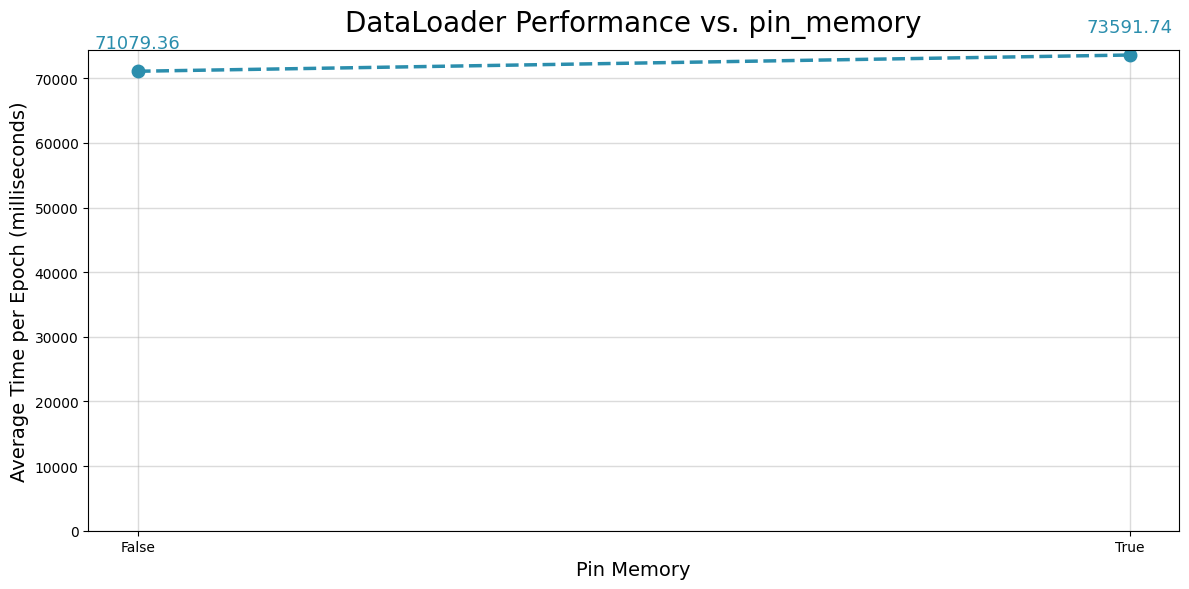

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. pin_memory'}, xlabel='Pin Memory', ylabel='Average Time per Epoch (milliseconds)'>)

In [37]:
helper_utils.plot_performance_summary(
    pin_memory_times, 
    title="DataLoader Performance vs. pin_memory", 
    xlabel="Pin Memory", 
    ylabel="Average Time per Epoch (milliseconds)"
)

If `pin_memory=True` shows little or no gain here, that is not unusual on a Mac-first workflow. Keeping the setting explicit in the notebook is still useful because it documents that the decision was measured rather than assumed, rather than copied from a generic training recipe.


### 1.4 Test `prefetch_factor`

Finally, we tune how many future batches each worker prepares in advance. `prefetch_factor` matters only when workers are already enabled, so this sweep is best interpreted as a refinement after the earlier `num_workers` and `batch_size` choices.


In [38]:
# Define the list of prefetch_factor values to test
prefetch_factors_to_test = [2, 4, 6, 8]

In [39]:
def experiment_prefetch_factor(prefetch_factors_to_test, trainset, device):
    # Initialize a dictionary to store the results
    prefetch_factor_times = {}

    # Loop through each prefetch factor you want to test
    for pf in prefetch_factors_to_test:
        print(f"--- Testing prefetch_factor = {pf} ---")
        
        # Create a new DataLoader instance for each specific test, using the optimal settings
        loader = DataLoader(trainset, 
                            batch_size=32, # Use the most efficient batch_size parameter
                            shuffle=True, 
                            num_workers=4, # Use the most efficient num_workers parameter
                            pin_memory=False, # Use the most efficient pin_memory choice
                            # The 'prefetch_factor' is set to the current value in the loop.
                            prefetch_factor=pf
                        )
        
        # Handle potential runtime errors
        try:
            # Time the data loading for one epoch and save it to the dictionary
            prefetch_factor_times[pf] = helper_utils.measure_average_epoch_time(loader, device)
        except RuntimeError as e:
            # If an error occurs, record it.
            print(f"\n❌ ERROR with prefetch_factor {pf}: {e}")
            prefetch_factor_times[pf] = float('inf')
            
        # Clean up the loader and call the garbage collector to free up memory
        # ensuring each test runs in a clean environment.
        del loader
        gc.collect()

        # Clear the PyTorch MPS cache to free up GPU memory.
        if torch.mps.is_available():
            torch.mps.empty_cache()

    return prefetch_factor_times

In [ ]:
# Run the experiment to measure data-loading time for different prefetch_factor values.
prefetch_factor_times = helper_utils.run_experiment(
    # A unique name for this experiment, used as the filename for the cached results.
    experiment_name="prefetch_factor_times", 
    # The function that contains the experiment logic.
    experiment_fcn=experiment_prefetch_factor,
    # The prefetch_factor values to iterate over.
    cases=prefetch_factors_to_test,
    # The dataset required by the experiment function.
    trainset=trainset, 
    # The computation device (for example, 'cpu' or 'mps') to use.
    device=device,
    # If False, load cached results when available.
    # If True, rerun the experiment and overwrite the old cache.
    rerun=False
)

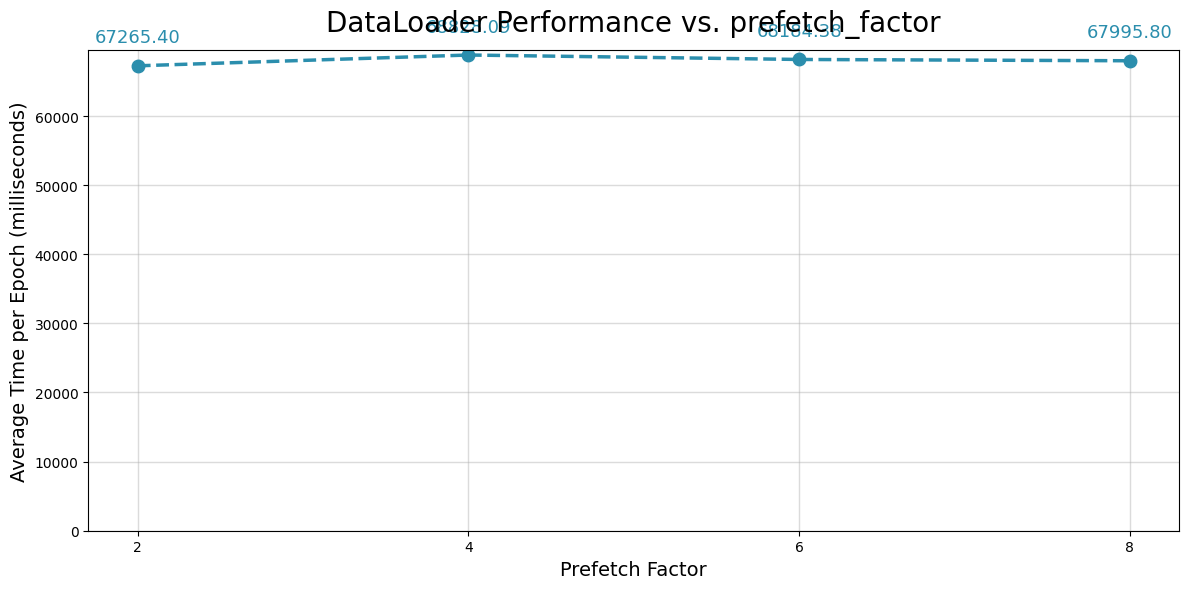

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'DataLoader Performance vs. prefetch_factor'}, xlabel='Prefetch Factor', ylabel='Average Time per Epoch (milliseconds)'>)

In [41]:
helper_utils.plot_performance_summary(
    prefetch_factor_times, 
    title="DataLoader Performance vs. prefetch_factor", 
    xlabel="Prefetch Factor", 
    ylabel="Average Time per Epoch (milliseconds)"
)

Taken together, the four sweeps provide an evidence-based loader configuration for the rest of the project. They also help separate true model-speed improvements from simpler pipeline bottlenecks.


## 2. Analyze Misclassifications with `Grad-CAM`

With training finished, we move from throughput to model behavior. This section reloads the best Stage 2 weights exported from Notebook 01, samples both correct and incorrect test predictions, and visualizes `Grad-CAM` heatmaps for the predicted class.

The objective is not just to showcase examples, but to understand whether the model attends to the dish itself, background cues, or visually similar ingredients.


Reloading the raw exported `state_dict` keeps this notebook decoupled from Lightning checkpoint internals. It also mirrors the kind of lightweight model reconstruction that downstream deployment or inference scripts often need.


In [6]:
# Load the best MobileNetV3 checkpoint.
weights_path = Path("../artifacts/weights/food101_mobilenetv3_stage2_best_state_dict.pth")

# Rebuild the model before loading the state dict.
best_model = tv_models.mobilenet_v3_large(weights=None)

# Replace the classifier for Food-101.
num_ftrs = best_model.classifier[-1].in_features
new_classifier = nn.Linear(in_features=num_ftrs, out_features=101)
best_model.classifier[-1] = new_classifier

state_dict = torch.load(weights_path, map_location=device, weights_only=True)
best_model.load_state_dict(state_dict)

# Move to the active device and switch to eval mode.
best_model = best_model.to(device)
best_model.eval()

print(f"Loaded best_model weights from: {weights_path}")

Loaded best_model weights from: ../artifacts/weights/food101_mobilenetv3_stage2_best_state_dict.pth


### 2.1 Analyze Misclassifications

We first sample a small set of correct and incorrect test predictions. This gives us concrete cases to inspect before explaining them with `Grad-CAM`, and it helps anchor the later heatmaps to visible success and failure modes rather than abstract averages.


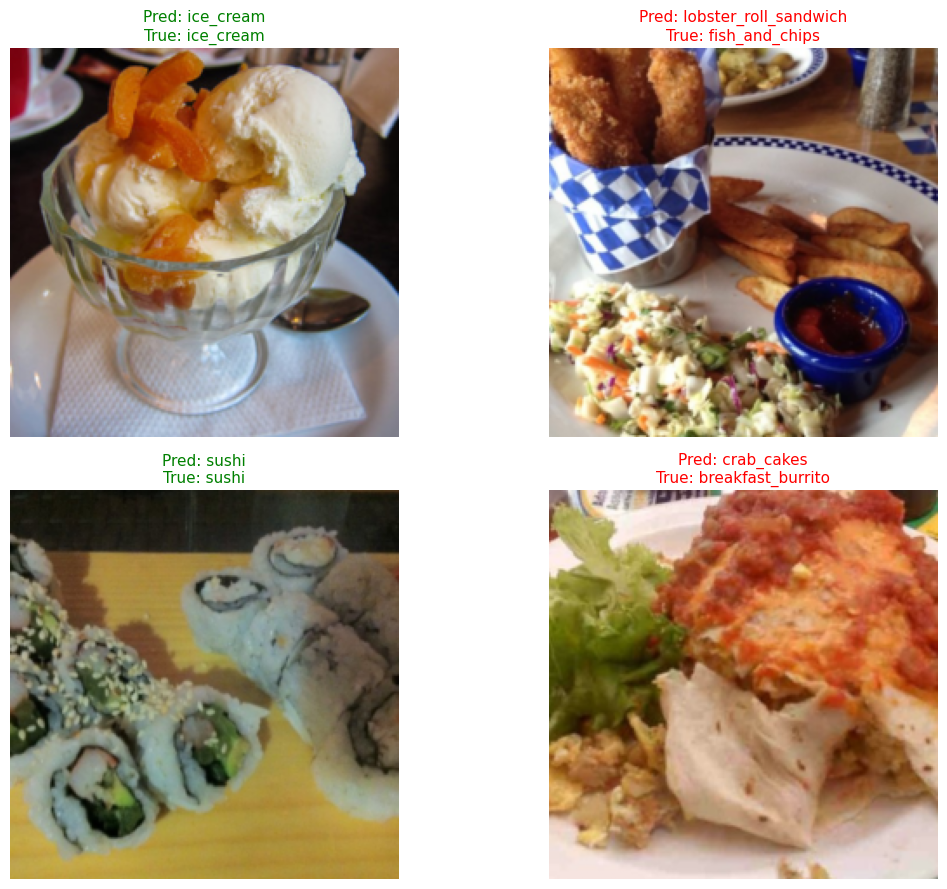

In [ ]:
# Sample a few correct and incorrect test predictions.
fig, axes, examples = helper_utils.show_test_prediction_examples(
    best_model,
    testset,
    num_correct=2,
    num_incorrect=2,
    batch_size=32,
    random_seed=SEED,
)

### 2.2 Show `Grad-CAM` Heatmaps

The heatmaps below explain the **predicted** class score for each sampled image. For correct examples, this shows where the model found evidence for the right class; for incorrect examples, it shows why the model preferred the wrong class.


In [ ]:
# Use the last feature block for Grad-CAM.
target_layers = [best_model.features[-1]]

cam = GradCAM(model=best_model, target_layers=target_layers)

In [ ]:
def tensor_to_rgb_for_cam(image_tensor):
    # Convert the normalized CHW tensor into an RGB image for Grad-CAM.
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Undo the ImageNet normalization.
    rgb = image_tensor.detach().cpu() * std + mean

    # Clamp the image and convert it to HWC format.
    rgb = rgb.clamp(0, 1).permute(1, 2, 0).numpy()

    # Grad-CAM utilities expect float32 input.
    return rgb.astype(np.float32)

In [ ]:
def build_gradcam_examples(grouped_examples, *, target_mode="pred"):
    # Convert the sampled predictions into display-ready Grad-CAM results.
    rendered_examples = []

    for example in grouped_examples:
        # Read the image tensor and its predicted and true labels.
        image_tensor = example["image_tensor"]
        pred_label = example["pred_label"]
        true_label = example["true_label"]

        # Decide whether Grad-CAM should explain the predicted class or the ground-truth class.
        if target_mode == "pred":
            target_label = pred_label
            target_label_name = "Pred"
        elif target_mode == "true":
            target_label = true_label
            target_label_name = "True"
        else:
            raise ValueError("`target_mode` must be either 'pred' or 'true'.")

        # Add the batch dimension required by Grad-CAM and move the tensor to `device`.
        input_tensor = image_tensor.unsqueeze(0).to(device)

        # Tell Grad-CAM which class logit to backpropagate for the heatmap.
        targets = [ClassifierOutputTarget(target_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        # Convert the tensor back to RGB and overlay the heatmap on the image.
        rgb_image = tensor_to_rgb_for_cam(image_tensor)
        cam_image = show_cam_on_image(rgb_image, grayscale_cam, use_rgb=True)

        # Store the rendered overlay together with the labels needed for plotting.
        rendered_example = {
            "image_tensor": image_tensor,
            "pred_label": pred_label,
            "true_label": true_label,
            "target_label": target_label,
            "target_label_name": target_label_name,
            "cam_image": cam_image,
        }

        rendered_examples.append(rendered_example)

    return rendered_examples

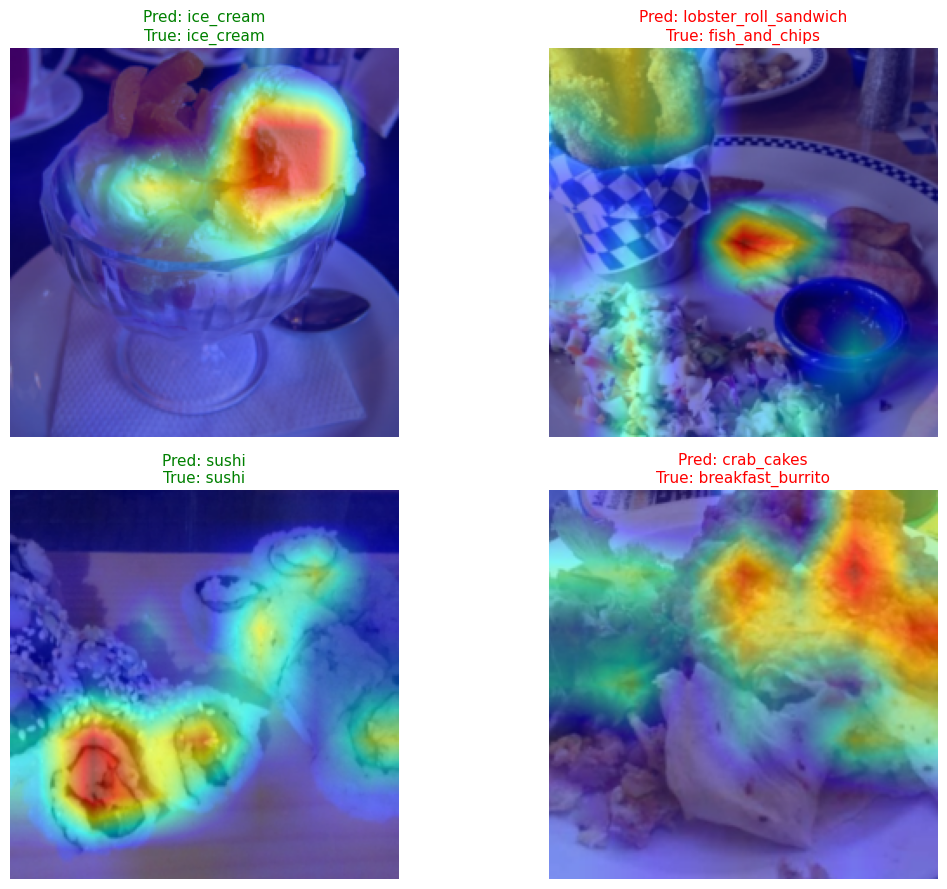

In [ ]:
# Build Grad-CAM overlays for the sampled correct and incorrect examples.
gradcam_examples = {
    "correct_examples": build_gradcam_examples(examples["correct_examples"], target_mode="pred"),
    "incorrect_examples": build_gradcam_examples(examples["incorrect_examples"], target_mode="pred"),
}

# Plot the stored overlays.
fig, axes = helper_utils.show_test_prediction_gradcam_examples(
    gradcam_examples,
    class_names=testset.classes,
)

Because the target is the predicted class logit, incorrect examples are especially informative: a heatmap concentrated on background context, garnish, or only part of the dish often reveals *why* the model chose the wrong label rather than merely showing that it was wrong.


## 3. Pruning

This notebook evaluates a cautious pruning variant rather than aggressive global unstructured pruning. The code below copies the best Stage 2 model, targets only a small set of late pointwise convolution layers, and applies one structured channel-pruning pass.

The key question is not just whether sparsity increases, but whether the resulting model preserves enough accuracy and produces a real latency benefit in deployment-style evaluation.


In [7]:
# Use one fixed batch size for pruning evaluation.
batch_size = 32
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

In [8]:
# Copy `best_model` before pruning.
pruned_model = copy.deepcopy(best_model).to(device).eval()

In [9]:
# Record the baseline test accuracy.
base_accuracy = helper_utils.compute_accuracy(pruned_model, test_loader, device)
print(f"Model accuracy: {base_accuracy:.4f}")

Computing Accuracy:   0%|          | 0/790 [00:00<?, ?it/s]

Computing Accuracy: 100%|██████████| 790/790 [00:45<00:00, 17.33it/s]


Model accuracy: 0.8276


In [ ]:
# Collect the layers whose weights will be included in global pruning.
def _iter_prunable_parameters(model, num_last_conv_layers=4):
    conv_candidates = []

    for module_name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            # Keep the first stem convolution dense to avoid harming low-level feature extraction.
            if module_name == "features.0.0":
                continue
            # Skip depthwise convolutions and keep only standard or pointwise convolutions.
            if module.groups != 1:
                continue
            # Keep only pointwise convolutions for a safer pruning pass.
            if module.kernel_size != (1, 1):
                continue

            conv_candidates.append((module_name, module))

    # Only prune the final few eligible conv layers.
    selected_convs = conv_candidates[-num_last_conv_layers:]
    return selected_convs

# Remove the pruning wrappers and turn masked weights back into normal parameters.
def finalize_pruning(model):
    for _, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if hasattr(module, "weight_orig") and hasattr(module, "weight_mask"):
                prune.remove(module, "weight")
    return model

In [ ]:
# Apply one global L1 pruning pass.
def prune_model(model, amount=0.1, num_last_conv_layers=4):
    # `amount` is the fraction of selected weights to prune.
    if not (0.0 <= amount <= 1.0):
        raise ValueError(f"amount must be in [0,1], got {amount}")

    selected_convs = _iter_prunable_parameters(
        model,
        num_last_conv_layers=num_last_conv_layers,
    )
    
    for module_name, module in selected_convs:
        prune.ln_structured(
            module,
            name="weight",
            amount=amount,
            n=2,  # Use L2 norm
            dim=0 # prune output channels
        )

    return model

In [12]:
# Verify the pruning effect.

# Measure the baseline sparsity and latency.
base = helper_utils.sparsity_report(pruned_model)
print("[BASE] global_sparsity:", base["global_sparsity"])
base_time = helper_utils.bench(pruned_model, device=device)
print("[BASE] time:", base_time)

# Apply the fixed global pruning configuration.
prune_model(pruned_model, amount=0.1, num_last_conv_layers=4)

after = helper_utils.sparsity_report(pruned_model)
print("[AFTER PRUNE] global_sparsity:", after["global_sparsity"])

after_acc = helper_utils.compute_accuracy(pruned_model, test_loader, device=device)
print("[AFTER PRUNE] accuracy:", after_acc)

pruned_time = helper_utils.bench(pruned_model, device=device)

print(f"\nInference time comparison:")
print(f"Base pruned_model: {base_time:.4f} seconds per batch")
print(f"Pruned pruned_model: {pruned_time:.4f} seconds per batch") 
print(f"Speedup: {base_time / pruned_time:.2f}x")

[BASE] global_sparsity: 0.0
[BASE] time: 0.019082858340116218
[AFTER PRUNE] global_sparsity: 0.017858172625281592


Computing Accuracy: 100%|██████████| 790/790 [00:45<00:00, 17.47it/s]


[AFTER PRUNE] accuracy: 0.7805940594059406

Inference time comparison:
Base pruned_model: 0.0191 seconds per batch
Pruned pruned_model: 0.0197 seconds per batch
Speedup: 0.97x


The measurements above should be interpreted jointly:

- sparsity tells us how many weights were removed
- test accuracy tells us how much predictive quality survived
- latency tells us whether the sparsity translated into actual runtime benefit


In [ ]:
# finalize_pruning(pruned_model)
# pruned_model.eval()

# print("Pruning wrappers removed. Finalized pruned_model is ready.")

The pruning experiment above is best read as a deployment decision, not just a sparsity demo. Higher sparsity alone is not enough: if test accuracy drops too much or measured latency barely improves, the compressed model is not actually a better artifact to ship.

In our case, structured pruning did not deliver a strong enough accuracy-latency trade-off, so pruning is documented here as an investigated option but is intentionally excluded from the final deployment path.


## 4. Quantization

Pruning was not selected, so the next deployment optimization is ONNX Runtime static INT8 quantization. Importantly, this section exports the **best Stage 2 PyTorch model** from Notebook 01, not the earlier baseline model, because the deployment candidate should come from the strongest available checkpoint.


### 4.1 Export to ONNX

We first move a copy of the selected model to CPU, switch it to evaluation mode, and export a dynamic-batch ONNX graph. This FP32 artifact becomes the common starting point for all later quantization candidates and the reference baseline for latency comparison.


In [ ]:
# Copy `best_model` and move the export copy to CPU.
export_model = copy.deepcopy(best_model).to("cpu")

In [ ]:
# Set the export model to evaluation mode 
export_model.eval()

print("Exporting model to ONNX...")

project_root = Path("..").resolve()
onnx_dir = project_root / "artifacts" / "onnx"
onnx_dir.mkdir(parents=True, exist_ok=True)

onnx_path = onnx_dir / "food101_model_FP32.onnx"
quantized_onnx_path = onnx_dir / "food101_model_INT8.onnx"

# Create a dummy input tensor with the expected shape
dummy_input = torch.randn(1, 3, 224, 224, device="cpu")

torch.onnx.export(
    export_model,                 # The trained PyTorch model to export (weights + graph). 
    dummy_input,                  # Dummy input used for tracing; keep the same (N,C,H,W) shape as inference.
    str(onnx_path),               # Output .onnx artifact path.
    export_params=True,           # Serialize the trained weights into the ONNX file.
    opset_version=17,             # ONNX opset version; chosen for compatibility with the ORT quantization flow.
    do_constant_folding=True,     # Fold constant subgraphs to reduce runtime compute.
    input_names=['input'],        # Stable input name; later calibration uses the ORT session input name.
    output_names=['output'],      # Stable output name for benchmarking/debugging.
    # Make batch dynamic so we can benchmark with different `batch_size` values.
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
)

print("\nModel successfully exported as food101_model_FP32.onnx")

### 4.2 Static Quantization with `onnxruntime`

Static quantization needs calibration data, so the notebook rebuilds the training split with deterministic evaluation transforms, samples a balanced subset across all classes, and feeds that subset through an ONNX Runtime calibration reader.

Rather than quantizing every operator blindly, the code compares several selective quantization candidate sets and keeps only artifacts that satisfy the accuracy constraint.


In [ ]:
# Validate the exported FP32 ONNX model before quantization so graph issues surface early.
onnx.checker.check_model(onnx.load(str(onnx_path)))

In [ ]:
# Load the baseline ONNX model into one CPU session so later timing stays comparable.
fp32_ort_session = ort.InferenceSession(
    str(onnx_path),
    providers=["CPUExecutionProvider"],
)

# Read the exported input name once because calibration and evaluation both reuse it.
input_name = fp32_ort_session.get_inputs()[0].name

In [ ]:
# Rebuild the training split with the deterministic evaluation transform for calibration.
calibration_dataset = datasets.Food101(
    root="../data",
    split="train",
    transform=VAL_TRANSFORM,
    download=False,
)

# Open one label-only view of the same split so balanced sampling does not pay transform cost.
calibration_label_dataset = datasets.Food101(
    root="../data",
    split="train",
    download=False,
)

In [ ]:
# Read the training labels once before building the balanced calibration subset.
if hasattr(calibration_label_dataset, "_labels"):
    calibration_labels = [int(label) for label in calibration_label_dataset._labels]
else:
    calibration_labels = [
        int(calibration_label_dataset[idx][1])
        for idx in range(len(calibration_label_dataset))
    ]

# Sample the same number of calibration images from every class.
calibration_samples_per_class = 10
class_to_indices = {
    class_idx: []
    for class_idx in range(len(calibration_dataset.classes))
}

# Group dataset indices by class label first so each class can be sampled independently.
for sample_idx, label in enumerate(calibration_labels):
    class_to_indices[label].append(sample_idx)

# Use a seeded RNG so the calibration subset stays reproducible across reruns.
rng = random.Random(SEED)
balanced_calibration_indices = []

# Sample each class separately and fail early if one class does not have enough images.
for class_idx, class_name in enumerate(calibration_dataset.classes):
    class_indices = class_to_indices[class_idx]
    if len(class_indices) < calibration_samples_per_class:
        raise ValueError(
            f"Class '{class_name}' has only {len(class_indices)} samples, which is fewer than "
            f"the requested calibration_samples_per_class={calibration_samples_per_class}."
        )

    balanced_calibration_indices.extend(
        rng.sample(class_indices, calibration_samples_per_class)
    )

# Sort the sampled indices once so the subset iteration order stays stable.
balanced_calibration_indices.sort()
calibration_subset = torch.utils.data.Subset(
    calibration_dataset,
    balanced_calibration_indices,
)

# Report the final calibration-set size used during static quantization.
print(
    f"Calibration subset size: {len(calibration_subset)} "
    f"({calibration_samples_per_class} samples per class)"
)

In [ ]:
# Feed the balanced calibration subset to ORT one image at a time for a simple calibration pass.
calibration_loader = DataLoader(
    calibration_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

The calibration reader feeds the same balanced subset to every candidate, which keeps the search fair. This matters because differences between quantization candidates should come from operator selection, not from different calibration data.


In [ ]:
class Food101CalibrationDataReader(CalibrationDataReader):
    def __init__(self, data_loader, input_name):
        self.data_loader = data_loader
        self.input_name = input_name
        self._iterator = iter(self.data_loader)

    def get_next(self):
        try:
            images, _ = next(self._iterator)
        except StopIteration:
            return None

        # Return one NumPy batch keyed by ORT's exported input name.
        # ORT static quantization expects float32 inputs; keep memory contiguous for throughput.
        return {
            self.input_name: np.ascontiguousarray(
                images.cpu().numpy().astype(np.float32)
            )
        }

    def rewind(self):
        # Reset the iterator so each quantization candidate sees identical calibration batches.
        self._iterator = iter(self.data_loader)

In [ ]:
# Define the selective static-quantization candidates to compare under the same accuracy target.

# Keep only candidates whose test accuracy >= this threshold
minimum_quantized_accuracy = 0.80
quantization_candidates = [
    {
        "label": "Conv + MatMul + Gemm",
        "suffix": "conv_matmul_gemm",
        # Selective quantization: quantize only these operator types (others stay FP32).
        "op_types_to_quantize": ["Conv", "MatMul", "Gemm"],
    },
    {
        "label": "Conv Only",
        "suffix": "conv_only",
        "op_types_to_quantize": ["Conv"],
    },
    {
        "label": "MatMul + Gemm Only",
        "suffix": "matmul_gemm_only",
        "op_types_to_quantize": ["MatMul", "Gemm"],
    },
]

The candidate-selection rule is intentionally strict: first satisfy the minimum accuracy threshold, then prefer the fastest remaining artifact. That prevents a tiny speedup from winning if it comes with a meaningful accuracy regression.


In [ ]:
# Store one summary row per candidate while tracking the fastest model that still meets the accuracy target.
quantization_search_rows = []
selected_quantized_label = None
selected_quantized_onnx_path = None
selected_quantized_accuracy = None
selected_quantized_time = None
selected_quantized_ort_session = None

for candidate in quantization_candidates:
    # Save each candidate under one stable artifact name so later inspection stays straightforward.
    candidate_onnx_path = onnx_dir / f"food101_model_INT8_{candidate['suffix']}.onnx"
    calibration_data_reader = Food101CalibrationDataReader(
        calibration_loader,
        input_name=input_name,
    )

    # Quantize this candidate using the same calibration data so only `op_types_to_quantize` differs.
    # Using QDQ format keeps the quant/dequant nodes explicit in the exported artifact.
    print(f"--- Quantizing Candidate: {candidate['label']} ---")
    quantize_static(
        model_input=str(onnx_path),
        model_output=str(candidate_onnx_path),
        calibration_data_reader=calibration_data_reader,
        quant_format=QuantFormat.QDQ,                                   # Export explicit Q/DQ nodes.
        activation_type=QuantType.QInt8,                                # Signed INT8 activations.
        weight_type=QuantType.QInt8,                                    # Signed INT8 weights.
        per_channel=True,                                               # Per-output-channel weight quantization.
        calibrate_method=CalibrationMethod.Percentile,                  # Percentile-based range estimation (robust to outliers).
        op_types_to_quantize=candidate["op_types_to_quantize"],         # Selective quantization over operator types.
    )

    # Re-open the quantized artifact and evaluate it using the same CPU runtime as the FP32 baseline.
    # This isolates the effect of quantization (not runtime/provider differences).
    onnx.checker.check_model(onnx.load(str(candidate_onnx_path)))
    candidate_ort_session = ort.InferenceSession(
        str(candidate_onnx_path),
        providers=["CPUExecutionProvider"],
    )
    # Accuracy is measured end-to-end on `test_loader` to validate the quantized graph.
    candidate_accuracy = helper_utils.compute_onnx_accuracy(
        candidate_ort_session,
        test_loader,
    )
    # Latency benchmark uses the same helper settings for fair comparison across candidates.
    candidate_time = helper_utils.bench_onnx_session(
        candidate_ort_session,
        batch_size=32,
        image_size=224,
    )
    candidate_size_mb = helper_utils.get_onnx_artifact_size_mb(candidate_onnx_path)
    # Guardrail: only keep candidates whose test accuracy is above the deployment threshold.
    meets_accuracy_constraint = candidate_accuracy >= minimum_quantized_accuracy

    # Record every searched configuration so the notebook output keeps the full comparison.
    quantization_search_rows.append(
        {
            "Configuration": candidate["label"],
            "Model Size (MB)": candidate_size_mb,
            "Inference Latency (ms)": candidate_time * 1e3,
            "Accuracy (%)": candidate_accuracy * 100,
            "Meets Accuracy >= 80%": meets_accuracy_constraint,
        }
    )

    # Keep the fastest candidate among those that still satisfy the 0.80 accuracy constraint.
    if meets_accuracy_constraint and (
        selected_quantized_time is None or candidate_time < selected_quantized_time
    ):
        selected_quantized_label = candidate["label"]
        selected_quantized_onnx_path = candidate_onnx_path
        selected_quantized_accuracy = candidate_accuracy
        selected_quantized_time = candidate_time
        selected_quantized_ort_session = candidate_ort_session

In [65]:
# Stop early if no candidate satisfies the deployment accuracy target.
if selected_quantized_onnx_path is None:
    raise RuntimeError(
        "No selective static-quantization candidate satisfied the accuracy >= 0.80 constraint."
    )

# Expose the selected candidate under shared variable names for the final comparison cells.
quantized_onnx_path = selected_quantized_onnx_path
quantized_ort_session = selected_quantized_ort_session
quantized_onnx_accuracy = selected_quantized_accuracy
quantized_onnx_time = selected_quantized_time

print("Selected quantization candidate:")
print(selected_quantized_label)

Selected quantization candidate:
MatMul + Gemm Only


### 4.3 Compare the Best Selective Quantized Artifact

Once the candidate search finishes, we benchmark the selected INT8 artifact against the FP32 ONNX baseline under the same `CPUExecutionProvider`.

Accuracy is measured on the same test loader used elsewhere in the notebook, and latency is measured with the same helper settings (`batch_size=32`, `image_size=224`). That makes the final table a deployment-focused comparison instead of an apples-to-oranges benchmark.


In [ ]:
# Measure the baseline ONNX session again with the same helper settings used for the selected INT8 model.
fp32_onnx_accuracy = helper_utils.compute_onnx_accuracy(
    fp32_ort_session,
    test_loader,
)
fp32_onnx_time = helper_utils.bench_onnx_session(
    fp32_ort_session,
    batch_size=32,
    image_size=224,
)

In [66]:
# Compare the baseline FP32 artifact and the selected INT8 artifact in one final table.
onnx_quantization_comparison_df = helper_utils.build_onnx_quantization_comparison_df(
    onnx_path,
    quantized_onnx_path,
    fp32_time_s=fp32_onnx_time,
    quantized_time_s=quantized_onnx_time,
    fp32_acc=fp32_onnx_accuracy,
    quantized_acc=quantized_onnx_accuracy,
    fp32_label="Baseline ONNX (FP32)",
    quantized_label=f"{selected_quantized_label} (Static INT8)",
)

onnx_quantization_comparison_df

,Baseline ONNX (FP32),MatMul + Gemm Only (Static INT8),Change
Model Size (MB),16.851763,12.952959,3.898804
Inference Latency (ms),69.905278,68.989541,0.915738
Accuracy (%),82.764356,82.744554,-0.019802


The comparison table above is the practical answer to the quantization section: it tells us whether the selected INT8 artifact is actually better than the FP32 export once accuracy, latency, and artifact size are viewed together.


## 5. Inference

The final cells run a small end-to-end inference demo with the selected quantized ONNX model. This is not another benchmark; it is a quick sanity check that the exported deployment artifact can load, run, and produce readable predictions on real test images.


In [ ]:
# Load the ONNX model into an ONNX Runtime inference session
int8_ort_session = ort.InferenceSession(str(quantized_onnx_path))

# Get the name of the model's input layer
input_name = int8_ort_session.get_inputs()[0].name

In [ ]:
# Get a batch of validation data to run predictions on
test_iter = iter(test_loader)
images, labels = next(test_iter)

# Use the first 4 images of the batch for prediction
input_data = images[:4].cpu().numpy()
# Get the corresponding true labels
true_labels = labels[:4].numpy()

Displaying predictions from the ONNX model...



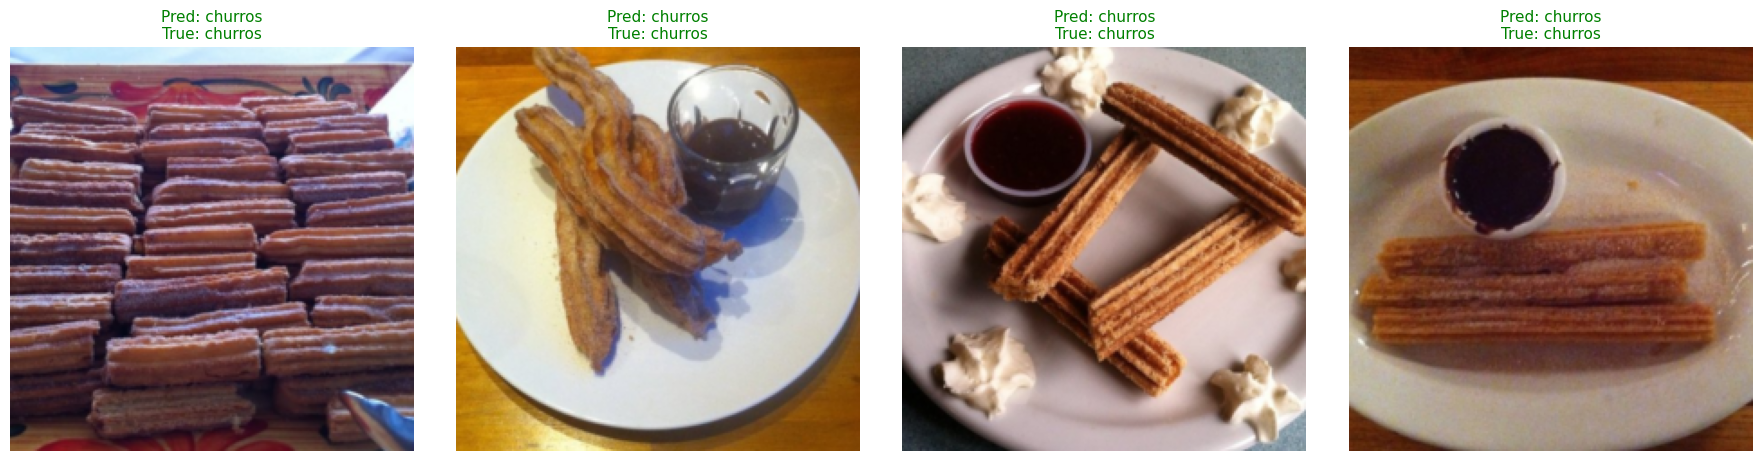

(<Figure size 1800x450 with 4 Axes>,
 array([[<Axes: title={'center': 'Pred: churros\nTrue: churros'}>,
         <Axes: title={'center': 'Pred: churros\nTrue: churros'}>,
         <Axes: title={'center': 'Pred: churros\nTrue: churros'}>,
         <Axes: title={'center': 'Pred: churros\nTrue: churros'}>]],
       dtype=object))

In [70]:
# Run inference using the ONNX Runtime session
ort_outputs = int8_ort_session.run(None, {input_name: input_data})
# Extract the predictions from the output
predictions = ort_outputs[0]

print("Displaying predictions from the ONNX model...\n")
# Visualize the predictions against the true labels
helper_utils.show_prediction_grid(input_data, true_labels, predictions)